In [1]:
# === Cell 1: imports + load + train/test split ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

DATA_CACHE   =  Path('data') / 'features'

df = pd.read_parquet(DATA_CACHE / 'cereal_features.parquet')
print(f'Loaded: {df.shape}')

# Chronological split: последние 20 недель → test
all_weeks = pd.Series(sorted(df['WEEK_END_DATE'].unique()))
TEST_WEEKS = 20
split_date = all_weeks.iloc[-TEST_WEEKS]
print(f'Split date: {split_date.date()}')
print(f'Train: до {split_date.date()} (исключительно)')
print(f'Test : от {split_date.date()} и позже')

train_df = df[df['WEEK_END_DATE'] < split_date].copy()
test_df  = df[df['WEEK_END_DATE'] >= split_date].copy()

print(f'\nTrain: {train_df.shape}  ({train_df["WEEK_END_DATE"].nunique()} weeks)')
print(f'Test : {test_df.shape}  ({test_df["WEEK_END_DATE"].nunique()} weeks)')
print(f'Train date range: {train_df["WEEK_END_DATE"].min().date()} → {train_df["WEEK_END_DATE"].max().date()}')
print(f'Test  date range: {test_df["WEEK_END_DATE"].min().date()} → {test_df["WEEK_END_DATE"].max().date()}')

# Sanity check: убедимся, что все SKU и магазины есть в обеих частях
print(f'\nSKUs in train: {train_df["UPC"].nunique()}, in test: {test_df["UPC"].nunique()}')
print(f'Stores in train: {train_df["STORE_NUM"].nunique()}, in test: {test_df["STORE_NUM"].nunique()}')

Loaded: (169676, 40)
Split date: 2011-08-24
Train: до 2011-08-24 (исключительно)
Test : от 2011-08-24 и позже

Train: (150672, 40)  (136 weeks)
Test : (19004, 40)  (20 weeks)
Train date range: 2009-01-14 → 2011-08-17
Test  date range: 2011-08-24 → 2012-01-04

SKUs in train: 15, in test: 15
Stores in train: 77, in test: 77


In [2]:
# === Cell 2: OLS с постепенным добавлением контролей ===

# Подготовим one-hot для категориальных переменных
def build_design_matrix(data, include_upc=False, include_store=False,
                       include_time=False, include_promo=False):
    """Собирает матрицу признаков X для регрессии log_units ~ log_price + контроли."""
    parts = [data[['log_price']].copy()]

    if include_upc:
        upc_dummies = pd.get_dummies(data['UPC'], prefix='upc', drop_first=True, dtype=float)
        parts.append(upc_dummies)

    if include_store:
        store_dummies = pd.get_dummies(data['STORE_NUM'], prefix='store', drop_first=True, dtype=float)
        parts.append(store_dummies)

    if include_time:
        # Сезонность недели через 52 dummy + year + holiday
        week_dummies = pd.get_dummies(data['week_of_year'], prefix='wk', drop_first=True, dtype=float)
        year_dummies = pd.get_dummies(data['year'], prefix='yr', drop_first=True, dtype=float)
        parts.extend([week_dummies, year_dummies, data[['is_holiday_week']].astype(float)])

    if include_promo:
        promo_dummies = pd.get_dummies(data['promo_type'], prefix='promo', drop_first=True, dtype=float)
        parts.append(promo_dummies)

    X = pd.concat(parts, axis=1)
    X = sm.add_constant(X)
    return X

y_train = train_df['log_units']

specs = [
    ('M1: log_price only',                  dict()),
    ('M2: + UPC FE',                        dict(include_upc=True)),
    ('M3: + UPC + store + time',            dict(include_upc=True, include_store=True, include_time=True)),
    ('M4: + UPC + store + time + promo',    dict(include_upc=True, include_store=True, include_time=True, include_promo=True)),
]

results = []
for label, kwargs in specs:
    X_train = build_design_matrix(train_df, **kwargs)
    model = sm.OLS(y_train, X_train).fit()
    elasticity = model.params['log_price']
    se = model.bse['log_price']
    ci_low, ci_high = elasticity - 1.96 * se, elasticity + 1.96 * se
    results.append({
        'spec': label,
        'elasticity': elasticity,
        'std_err': se,
        'ci_95': f'[{ci_low:+.2f}, {ci_high:+.2f}]',
        'r2': model.rsquared,
        'n_features': X_train.shape[1] - 1,
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                            spec  elasticity  std_err          ci_95       r2  n_features
              M1: log_price only   -0.559337 0.008734 [-0.58, -0.54] 0.026501           1
                    M2: + UPC FE   -2.593172 0.014036 [-2.62, -2.57] 0.322793          15
        M3: + UPC + store + time   -2.842337 0.011530 [-2.86, -2.82] 0.574694         146
M4: + UPC + store + time + promo   -1.759926 0.015580 [-1.79, -1.73] 0.629095         150


In [3]:
# === Cell 3: LightGBM как чисто предиктивная модель спроса ===
import lightgbm as lgb

# Целевая переменная и фичи
TARGET = 'log_units'
FEATURES = [
    'log_price', 'log_base_price', 'discount_depth',     # ценовые
    'upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code',  # категориальные коды
    'size_oz', 'price_per_oz',                            # продуктовые
    'month', 'week_of_year', 'quarter', 'year',           # временные
    'is_holiday_week', 'promo_code',                      # сезон и промо
    'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS',          # магазинные
]

# Указываем какие фичи категориальные — LightGBM умеет с ними работать напрямую
CATEGORICAL = ['upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code', 'promo_code']

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

# Модель — стартовые гиперпараметры умеренные, без оптимизации
model_gbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=-1,
)

model_gbm.fit(
    X_train, y_train,
    categorical_feature=CATEGORICAL,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50)],
)

# Предсказания на test
y_pred_log = model_gbm.predict(X_test)

# Метрики в log-пространстве
print('\n=== GBM performance (log space) ===')
print(f'R²   on test : {r2_score(y_test, y_pred_log):.3f}')
print(f'MAE  on test : {mean_absolute_error(y_test, y_pred_log):.3f}')

# Метрики в исходном пространстве — для интерпретации
y_test_units  = np.exp(y_test)
y_pred_units  = np.exp(y_pred_log)
mae_units = np.mean(np.abs(y_test_units - y_pred_units))
mape      = np.mean(np.abs(y_test_units - y_pred_units) / y_test_units) * 100
print('\n=== GBM performance (units space) ===')
print(f'MAE  on test : {mae_units:.1f} units')
print(f'MAPE on test : {mape:.1f}%')

# Для сравнения — OLS M4 на тех же test-данных
X_test_ols = build_design_matrix(test_df, include_upc=True, include_store=True,
                                  include_time=True, include_promo=True)
# Перестроим OLS на train с теми же контролями
X_train_ols = build_design_matrix(train_df, include_upc=True, include_store=True,
                                   include_time=True, include_promo=True)

# Выровним колонки между train и test (могут быть разные dummy)
X_test_ols = X_test_ols.reindex(columns=X_train_ols.columns, fill_value=0)

ols_m4 = sm.OLS(train_df['log_units'], X_train_ols).fit()
y_pred_ols_log = ols_m4.predict(X_test_ols)

print('\n=== OLS M4 performance (log space) ===')
print(f'R²   on test : {r2_score(y_test, y_pred_ols_log):.3f}')
print(f'MAE  on test : {mean_absolute_error(y_test, y_pred_ols_log):.3f}')

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[492]	valid_0's l2: 0.303809

=== GBM performance (log space) ===
R²   on test : 0.655
MAE  on test : 0.376

=== GBM performance (units space) ===
MAE  on test : 9.6 units
MAPE on test : 60.6%

=== OLS M4 performance (log space) ===
R²   on test : 0.453
MAE  on test : 0.502


In [4]:
# === Cell 4: где модель ошибается ===
import pandas as pd

eval_df = test_df.copy()
eval_df['y_true_log']  = y_test.values
eval_df['y_pred_log']  = y_pred_log
eval_df['y_true']      = np.exp(eval_df['y_true_log'])
eval_df['y_pred']      = np.exp(eval_df['y_pred_log'])
eval_df['abs_err_log'] = (eval_df['y_pred_log'] - eval_df['y_true_log']).abs()
eval_df['abs_err']     = (eval_df['y_pred'] - eval_df['y_true']).abs()
eval_df['ape']         = eval_df['abs_err'] / eval_df['y_true'] * 100

# Разбивка по объёму продаж
eval_df['units_bucket'] = pd.cut(
    eval_df['y_true'],
    bins=[0, 5, 10, 25, 50, 100, np.inf],
    labels=['1-5', '6-10', '11-25', '26-50', '51-100', '100+'],
)

bucket_stats = eval_df.groupby('units_bucket', observed=True).agg(
    n        =('y_true', 'size'),
    mae_log  =('abs_err_log', 'mean'),
    mae_units=('abs_err', 'mean'),
    mape     =('ape', 'mean'),
    median_ape=('ape', 'median'),
).round(2)
print('Error by sales volume bucket:')
print(bucket_stats)

# Также: какой R² если оценивать в units, а не в log?
print(f'\nR² in units space: {r2_score(eval_df["y_true"], eval_df["y_pred"]):.3f}')

# И медианная APE — менее чувствительна к выбросам
print(f'Median APE: {eval_df["ape"].median():.1f}%')

# Топ-10 худших предсказаний
print('\nWorst 10 predictions (by absolute error in units):')
worst = eval_df.nlargest(10, 'abs_err')[
    ['WEEK_END_DATE', 'STORE_NUM', 'UPC', 'DESCRIPTION',
     'y_true', 'y_pred', 'PRICE', 'on_promo', 'promo_type']
]
print(worst.to_string(index=False))

Error by sales volume bucket:
                 n  mae_log  mae_units    mape  median_ape
units_bucket                                              
1-5           1263     1.24       8.81  420.90      201.00
6-10          1716     0.53       6.26   84.85       53.95
11-25         7787     0.30       5.48   34.17       24.45
26-50         5259     0.28       9.16   25.66       21.85
51-100        2157     0.30      16.97   25.42       22.38
100+           822     0.26      39.31   22.62       19.19

R² in units space: 0.835
Median APE: 26.2%

Worst 10 predictions (by absolute error in units):
WEEK_END_DATE  STORE_NUM        UPC           DESCRIPTION  y_true     y_pred  PRICE  on_promo      promo_type
   2011-12-21      25027 1600027527 GM HONEY NUT CHEERIOS   756.0 389.079658   1.99         1 feature_display
   2011-12-14      19521 3800039118      KELL FROOT LOOPS   370.0  74.756918   1.99         1 feature_display
   2012-01-04       9825 1600027527 GM HONEY NUT CHEERIOS   605.0 330.40

Feature importance (by gain):
            feature          gain  split  gain_pct
         store_code 251788.148576   7379 29.278473
           upc_code 188358.383309   3505 21.902722
         promo_code 141798.865038    890 16.488680
     discount_depth  44061.862265   1283  5.123609
          log_price  37120.006236   2478  4.316395
         manuf_code  31851.485032    313  3.703760
SALES_AREA_SIZE_NUM  28311.517456    698  3.292125
       price_per_oz  27387.870176   2411  3.184721
       week_of_year  21666.267435   3971  2.519401
     log_base_price  18883.425227   2102  2.195806
 AVG_WEEKLY_BASKETS  16837.477856    471  1.957899
        subcat_code  16531.015538    644  1.922262
            size_oz  13073.961519    649  1.520269
               year  11646.602248   1688  1.354292
              month   5881.319488   1317  0.683893
           seg_code   3010.908401    328  0.350115
    is_holiday_week   1439.736026    290  0.167416
            quarter    328.202496     87  0.038164


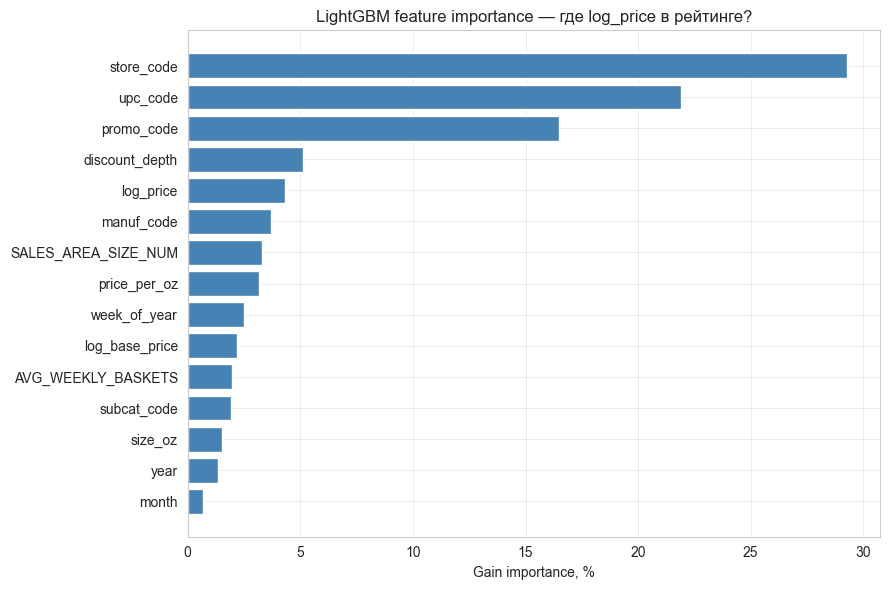

In [5]:
# === Cell 5: feature importance + price PDP ===

# Gain importance — вклад фичи в улучшение лосса при сплитах
importance_gain = pd.DataFrame({
    'feature': model_gbm.feature_name_,
    'gain': model_gbm.booster_.feature_importance(importance_type='gain'),
    'split': model_gbm.booster_.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

importance_gain['gain_pct'] = importance_gain['gain'] / importance_gain['gain'].sum() * 100
print('Feature importance (by gain):')
print(importance_gain.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(9, 6))
top = importance_gain.head(15)
ax.barh(top['feature'][::-1], top['gain_pct'][::-1], color='steelblue')
ax.set_xlabel('Gain importance, %')
ax.set_title('LightGBM feature importance — где log_price в рейтинге?')
plt.tight_layout()
plt.show()

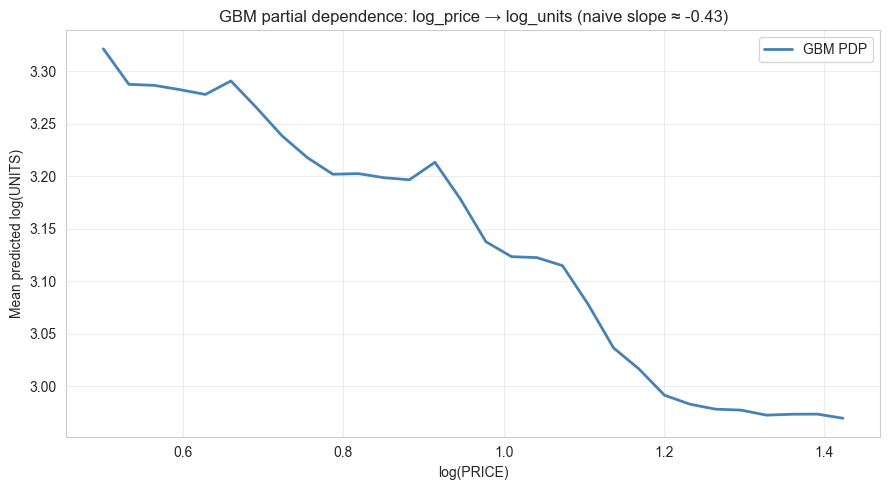


Naive GBM "elasticity" (PDP slope): -0.43

Comparison:
  M1 (pool OLS):         -0.56
  M2 (+ UPC FE):         -2.59
  M3 (+ UPC + store + time): -2.84
  M4 (+ promo):          -1.76
  GBM PDP:               -0.43


In [7]:
# === Cell 6: partial dependence log_price → log_units ===

sample_idx = np.random.RandomState(42).choice(len(X_train), size=10000, replace=False)
X_sample = X_train.iloc[sample_idx]

log_price_grid = np.linspace(X_train['log_price'].quantile(0.05),
                              X_train['log_price'].quantile(0.95), 30)

pdp_values = []
for lp in log_price_grid:
    X_modified = X_sample.copy()
    X_modified['log_price'] = lp
    pred = model_gbm.predict(X_modified).mean()
    pdp_values.append(pred)

pdp_values = np.array(pdp_values)

# Эффективная "эластичность" как наклон PDP в логах
elasticity_gbm = np.polyfit(log_price_grid, pdp_values, 1)[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(log_price_grid, pdp_values, color='steelblue', linewidth=2, label='GBM PDP')
ax.set_xlabel('log(PRICE)')
ax.set_ylabel('Mean predicted log(UNITS)')
ax.set_title(f'GBM partial dependence: log_price → log_units (naive slope ≈ {elasticity_gbm:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nNaive GBM "elasticity" (PDP slope): {elasticity_gbm:.2f}')
print(f'\nComparison:')
print(f'  M1 (pool OLS):         -0.56')
print(f'  M2 (+ UPC FE):         -2.59')
print(f'  M3 (+ UPC + store + time): -2.84')
print(f'  M4 (+ promo):          -1.76')
print(f'  GBM PDP:               {elasticity_gbm:.2f}')

In [9]:
# === Cell 7: сохранить артефакты для DML-ноутбука ===
import joblib

artifacts_dir = Path('data') / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Сохраним GBM-модель (может пригодиться для сравнений)
joblib.dump(model_gbm, artifacts_dir / 'gbm_demand.pkl')

# Сохраним сводку всех baseline-эластичностей
elasticity_baseline = {
    'pool_ols_M1':    -0.56,
    'per_sku_ols':    -2.51,
    'ols_upc_M2':     -2.59,
    'ols_full_M3':    -2.84,
    'ols_with_promo_M4': -1.76,
    'gbm_pdp':        -0.43,
}
pd.Series(elasticity_baseline).to_json(artifacts_dir / 'elasticity_baseline.json', indent=2)

# Сохраним train/test split, чтобы DML работал на тех же данных
train_df.to_parquet(artifacts_dir / 'train.parquet', index=False)
test_df.to_parquet(artifacts_dir / 'test.parquet', index=False)

print('Saved:')
for f in artifacts_dir.iterdir():
    print(f'  {f.name}: {f.stat().st_size / 1024:.1f} KB')

Saved:
  train.parquet: 2059.1 KB
  test.parquet: 324.0 KB
  gbm_demand.pkl: 2841.1 KB
  elasticity_baseline.json: 0.1 KB
